# top

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
print(sys.path)

%load_ext autoreload
%autoreload 2

['/mnt/ceph/users/blyo1/projects', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python310.zip', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/lib-dynload', '', '/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages']


# SOS data

torch.Size([32])
5.5


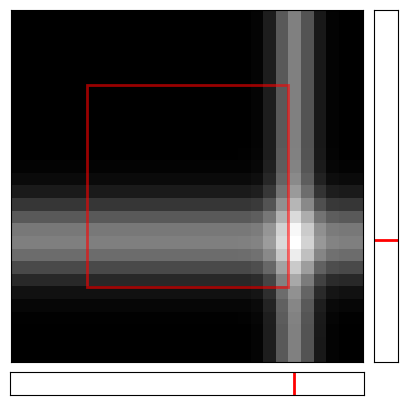

In [7]:
from matplotlib.gridspec import GridSpec

from a_datasets.sos.data import SOSDataset

# scalar encoding
dataset = SOSDataset(
    num_samples=1000, grid_size=28, sigma_x=0.8,
        sigma_y=1.5, holdout_center=False, only_sample_holdout=False, seed=46,
)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)
(data_x, data_y), target = next(iter(dataloader))

print(data_x.shape)

# plot
fig = plt.figure(figsize=(5, 5))
gs = GridSpec(2, 2, width_ratios=[15, 1], height_ratios=[15, 1], wspace=0.05, hspace=0.05)

# Main image
ax_main = fig.add_subplot(gs[0, 0])
ax_main.imshow(target[0].numpy().reshape(28, 28), cmap="gray")
ax_main.set_xticks([])
ax_main.set_yticks([])

# Bottom plot (x position indicator)
ax_bottom = fig.add_subplot(gs[1, 0], sharex=ax_main)
ax_bottom.axvline(data_x[0], color="red", lw=2)
ax_bottom.set_xlim(-0.5, 27.5)
ax_bottom.set_yticks([])

# Right plot (y position indicator)
ax_right = fig.add_subplot(gs[0, 1], sharey=ax_main)
ax_right.axhline(data_y[0], color="red", lw=2)
ax_right.set_ylim(27.5, -0.5)  # Inverted to match image coordinates
ax_right.set_xticks([])

# plot the holdout region
min_x_coord = min_y_coord = int(28 * 0.2) + 1 - 0.5
print(min_x_coord)
length_x = length_y = int(28 * 0.6)
ax_main.add_patch(
    plt.Rectangle((min_x_coord, min_y_coord), length_x, length_y, linewidth=2, edgecolor="red", facecolor="none", alpha=0.6)
)


# Hide the corner
ax_corner = fig.add_subplot(gs[1, 1])
ax_corner.axis("off")

plt.show()